# CÍL 5: Matplotlib

> Tento notebook je součástí cvičení 12 předmětu BPC-PRG.  
> Projdi ho postupně – každou buňku spusť klávesou **Shift+Enter**.  
> 📥 **[Stáhnout notebook](cviceni_12_matplotlib.ipynb)** &nbsp;|&nbsp; 📥 **[Stáhnout data (mpl_data.npz)](../mpl_data.npz)**


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Všechna data jsou předpřipravena – stáhni mpl_data.npz a načti:
d = np.load("mpl_data.npz")

t, ekg, resp        = d["t"], d["ekg"], d["resp"]
mri                 = d["mri"]
zatez               = [d["klid"], d["chuze"], d["beh"], d["sprint"]]
zdravi, diabetici   = d["zdravi"], d["diabetici"]


## Co je Matplotlib?

[**Matplotlib**](https://matplotlib.org/) je nejrozšířenější Python knihovna pro tvorbu grafů a vizualizací. Vznikla v roce 2003 jako náhrada za grafiku MATLABu – odtud jméno.

Její hlavní modul, který budeš téměř vždy importovat, se jmenuje **`pyplot`**. Poskytuje rozhraní inspirované MATLABem a umožňuje tvorbu grafů několika řádky kódu.

V biomedicíně ji využiješ na:

- vykreslení **časových řad** (EKG, dech, krevní tlak, teplota),
- zobrazení **medicínských snímků** (MRI, CT, histologické řezy) jako 2D matice,
- **statistické grafy** – boxploty pro srovnání skupin pacientů, histogramy pro rozložení hodnot,
- **vědecké publikace** – výstup ve formátu PDF/SVG s přesnou kontrolou nad každým detailem.

Matplotlib je úzce provázaný s NumPy – jako data přijímají funkce přímo numpy pole.

### Co vše lze vykreslit?

| Typ grafu          | Funkce         | Kdy ho použít                                       |
|--------------------|----------------|-----------------------------------------------------|
| Spojnicový         | `ax.plot()`    | Časové řady – EKG, dech, průběh léčby               |
| Sloupcový          | `ax.bar()`     | Srovnání kategorií – průměry skupin, výsledky měření |
| Bodový (scatter)   | `ax.scatter()` | Korelace dvou proměnných – výška vs váha            |
| Histogram          | `ax.hist()`    | Rozložení hodnot – glykémie, BMI, TF                |
| Boxplot            | `ax.boxplot()` | Mediány a rozptyl napříč skupinami pacientů         |
| Obrázek / heatmapa | `ax.imshow()`  | MRI, CT snímky, korelační matice                    |
| Výsečový           | `ax.pie()`     | Podíly – zastoupení diagnóz v populaci              |

> **Poznámka:** Pro interaktivní a webové grafy existují moderní alternativy jako **Plotly** nebo **Bokeh**. Matplotlib je ale základ, na kterém jsou postavené i vyšší knihovny jako **Seaborn** nebo **Pandas** `.plot()`.

## 3.1 Základní struktura matplotlib

Matplotlib má dvě vrstvy rozhraní:

- **`plt.plot()`** – rychlé globální funkce, dobré pro jeden jednoduchý graf,
- **`fig, ax = plt.subplots()`** – přímá práce s objekty Figure a Axes; doporučovaný přístup jakmile máš víc grafů nebo potřebuješ přesnou kontrolu.

Budeme používat druhý přístup – je přehlednější a lépe se škáluje na složitější vizualizace.

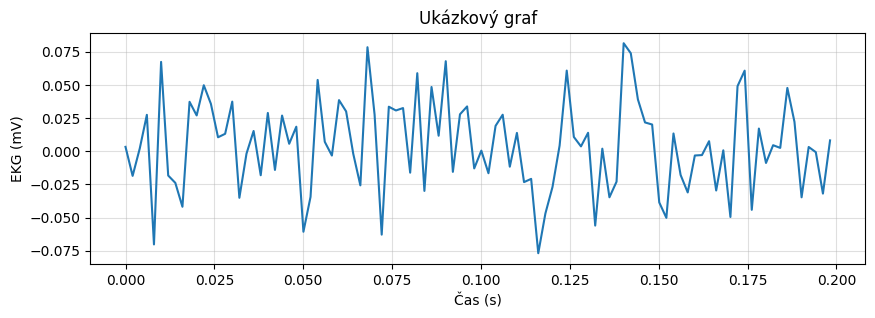

In [2]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:100], ekg[:100])
ax.set_title("Ukázkový graf")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.4)
plt.show()


## 3.2 Vykreslení signálu

Spojnicový graf je základní vizualizace pro časové řady – EKG, dech, krevní tlak, teplota.

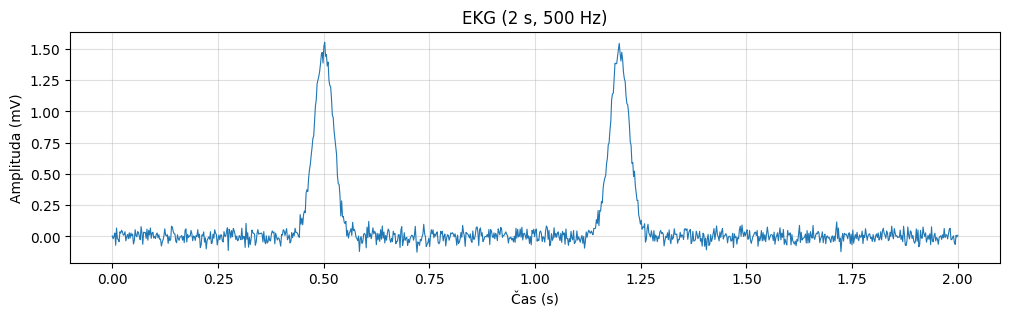

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.set_title("EKG (2 s, 500 Hz)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.grid(True, alpha=0.4)
plt.show()


### Více grafů pod sebou – `sharex=True`

`plt.subplots(2, 1, sharex=True)` vytvoří dva grafy sdílející osu X – ideální pro srovnání více kanálů (EKG + dech, EKG + tlak apod.).

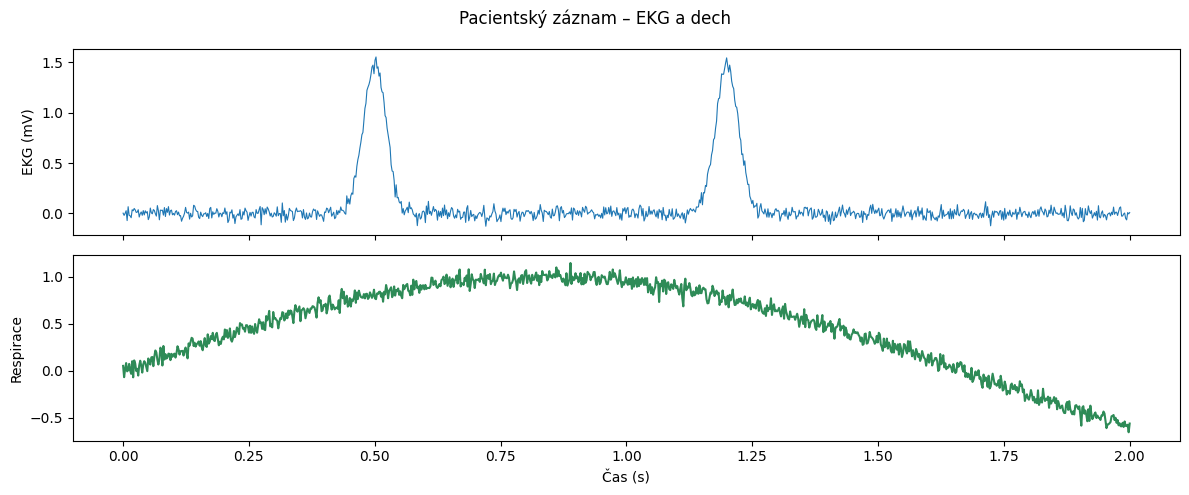

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t, ekg, linewidth=0.8)
ax1.set_ylabel("EKG (mV)")
ax2.plot(t, resp, color="seagreen")
ax2.set_ylabel("Respirace")
ax2.set_xlabel("Čas (s)")
fig.suptitle("Pacientský záznam – EKG a dech")
plt.tight_layout()
plt.show()


## 3.3 Zobrazení matice / obrazu

`imshow()` zobrazí 2D numpy pole jako obrázek nebo heatmapu – každá hodnota odpovídá barvě pixelu. Hodí se pro medicínské snímky (MRI, CT), korelační matice nebo síťové váhy v neuronových sítích.

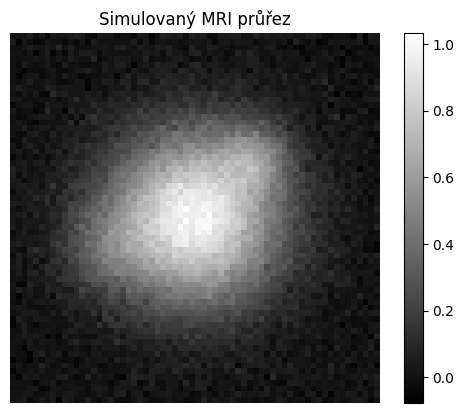

In [5]:
fig, ax = plt.subplots()
im = ax.imshow(mri, cmap="gray")
fig.colorbar(im)
ax.axis("off")
ax.set_title("Simulovaný MRI průřez")
plt.show()


> **Tip:** Pro medicínské obrazy se nejčastěji používá `cmap="gray"`. `viridis` je dobrou volbou pro vědecké heatmapy – je perceptuálně uniformní (stejné rozdíly v datech odpovídají stejně vnímaným rozdílům v barvě) a čitelná i při výtisku nebo pro barvoslepé.

## 3.4 Boxplot – statistické srovnání skupin

Boxplot je ideální pro srovnání rozložení hodnot napříč skupinami – různé pacienty, různé podmínky měření, různé diagnózy. Ukazuje medián, kvartily, vousy a odlehlé hodnoty.

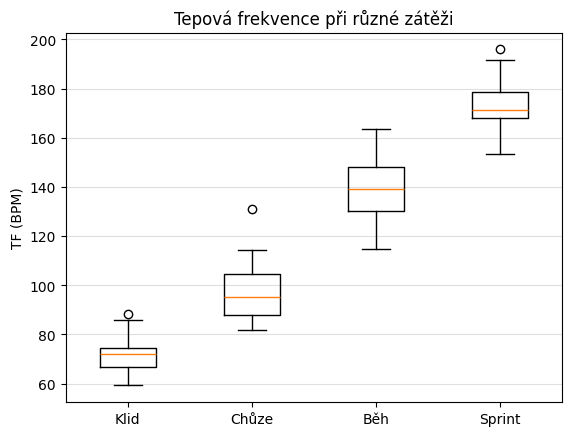

In [6]:
fig, ax = plt.subplots()
ax.boxplot(zatez, tick_labels=["Klid", "Chůze", "Běh", "Sprint"])
ax.set_title("Tepová frekvence při různé zátěži")
ax.set_ylabel("TF (BPM)")
ax.grid(True, axis="y", alpha=0.4)
plt.show()


## 3.5 Histogram – rozložení hodnot

Histogram ukazuje, jak jsou hodnoty rozloženy. Hodí se pro první pohled na data – je rozložení symetrické? Má odlehlé hodnoty? Odpovídá normálnímu rozložení?

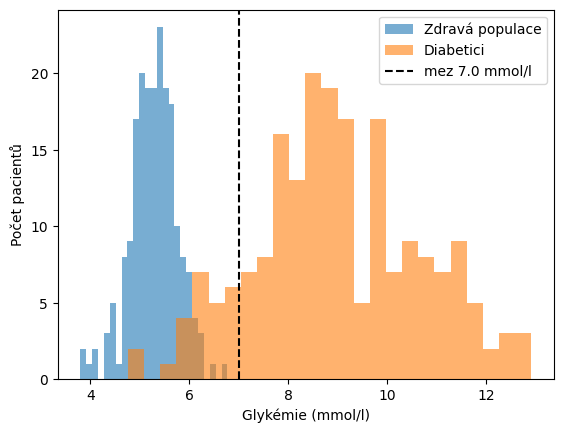

In [7]:
fig, ax = plt.subplots()
ax.hist(zdravi,    bins=25, alpha=0.6, label="Zdravá populace")
ax.hist(diabetici, bins=25, alpha=0.6, label="Diabetici")
ax.axvline(7.0, color="black", linestyle="--", label="mez 7.0 mmol/l")
ax.set_xlabel("Glykémie (mmol/l)")
ax.set_ylabel("Počet pacientů")
ax.legend()
plt.show()
